In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc
import pickle
import scvi

from cellina import CellinaModel
from utils import set_seed

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get dataset

In [4]:
set_seed(0)

In [5]:
adata = sc.read_h5ad("/data2/a330d/datasets/synthetic_spatial_adata_processed.h5ad")
#adata = sc.read("/data/a330d/projects/dsa/data/melanoma_cosmx_processed.h5ad")

In [6]:
seeds = range(5)

## Data splits

In [7]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    # Conditions
    is_fibro  = adata.obs["cell_type"].isin(["Fibroblast"])
    is_stress = adata.obs["region"] == "stressed"

    # Combine for test set
    test_mask = (is_stress) & (is_fibro)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [8]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [9]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [10]:
CellinaModel.setup_anndata(adata,
                           batch_key="batch",
                           labels_key='cell_type', 
                           domains_key='region', 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


In [12]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [12]:
epochs = 100
conditions = [True, False]

In [ ]:
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata, n_latent=64, classifier_lambda=0.2, discriminator_lambda=0.1, 
            condition_on_intrinsic=cond, use_observed_lib_size=True
        )
        model.train(
            max_epochs=epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            datasplitter_kwargs={
                "external_indexing": [train_idx, val_idx, test_idx],
            },
            plan_kwargs={'normalize_losses': True,
                         },
            enable_checkpointing=True,
            batch_size=2048,
            devices=[1],
        )

        model.save(f"{base_path}/trained/cond_z_{cond}_sim_seed_{seed}_{split}", overwrite=True)

# SCVI baseline

In [10]:
scvi.model.SCVI.setup_anndata(adata, batch_key="batch", layer="counts")

In [15]:
# Train scvi per-seed and evaluate marginal log-likelihood on the same test_idx
for seed in seeds:
    set_seed(seed)
    model = scvi.model.SCVI(adata, n_latent=64, use_observed_lib_size=True)
    model.train(
        max_epochs=epochs,
        check_val_every_n_epoch=1,
        early_stopping=True,
        early_stopping_patience=25,
        early_stopping_monitor="validation_loss",
        datasplitter_kwargs={
            "external_indexing": [train_idx, val_idx, test_idx],
        },
        batch_size=2048,
        devices=[1],
    )
    model.save(f"{base_path}/trained/scvi_sim_seed_{seed}_{split}", overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [01:06<00:00,  1.52it/s, v_num=1, train_loss_step=2.07e+3, train_loss_epoch=2.05e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:06<00:00,  1.52it/s, v_num=1, train_loss_step=2.07e+3, train_loss_epoch=2.05e+3]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


...

Epoch 100/100: 100%|██████████| 100/100 [01:06<00:00,  1.50it/s, v_num=1, train_loss_step=2.05e+3, train_loss_epoch=2.06e+3]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.



Epoch 100/100: 100%|██████████| 100/100 [01:05<00:00,  1.55it/s, v_num=1, train_loss_step=2.04e+3, train_loss_epoch=2.05e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:05<00:00,  1.53it/s, v_num=1, train_loss_step=2.04e+3, train_loss_epoch=2.05e+3]


# Evaluate Marginal LL via Importance Sampling to see holdout data fit

In [16]:
n_mc_samples = 500

In [17]:
results = {str(cond): [] for cond in conditions}
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        save_path = f"{base_path}/trained/cond_z_{cond}_sim_seed_{seed}_{split}"

        model = CellinaModel.load(save_path, adata)

        mll = model.get_marginal_ll(adata=adata[adata.obs['is_holdout']], 
                                    n_mc_samples=n_mc_samples,
                                    return_mean=True)
        results[str(cond)].append(mll)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_True_sim_seed_0_ood/model.pt already        
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_True_sim_seed_1_ood/model.pt already        
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_False_sim_seed_2_ood/model.pt already       
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_False_sim_seed_3_ood/model.pt already       
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_False_sim_seed_4_ood/model.pt already       
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [18]:
with open(f"../results/mll_sim_results_{split}.pkl", "wb") as f:
    pickle.dump(results, f)

## scvi MLL

In [14]:
save_path = f"{base_path}/trained/scvi_sim_seed_0_ood"
model = scvi.model.SCVI.load(save_path, adata)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_0_ood/model.pt already downloaded    


In [16]:
lat = model.get_latent_representation(adata[adata.obs['cell_type']=='Fibroblast'])

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [18]:
import anndata as ad
adata_fib = ad.AnnData(X=lat, obs=adata[adata.obs['cell_type']=='Fibroblast'].obs)

In [21]:
sc.pp.neighbors(adata_fib, n_neighbors=15, use_rep='X')
sc.tl.umap(adata_fib)

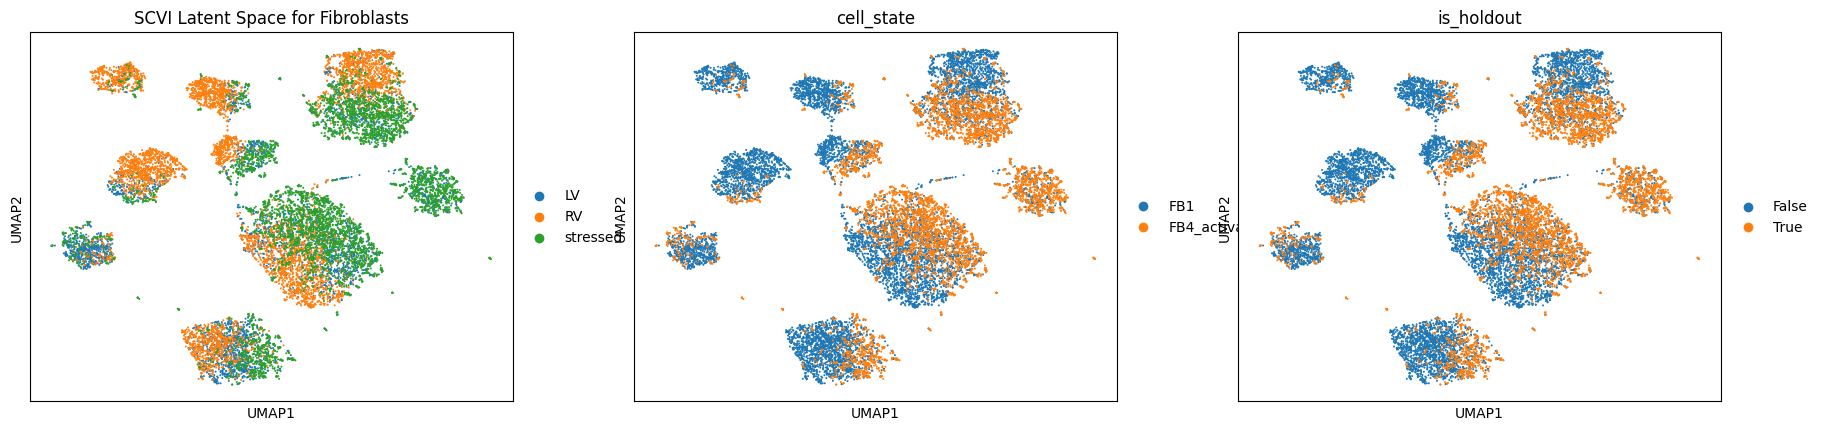

In [22]:
sc.pl.umap(adata_fib, color=['region', 'cell_state', 'is_holdout'], title='SCVI Latent Space for Fibroblasts')

In [23]:
adata.obsm['scvi'] = model.get_latent_representation(adata)

In [27]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')
sc.tl.umap(adata)

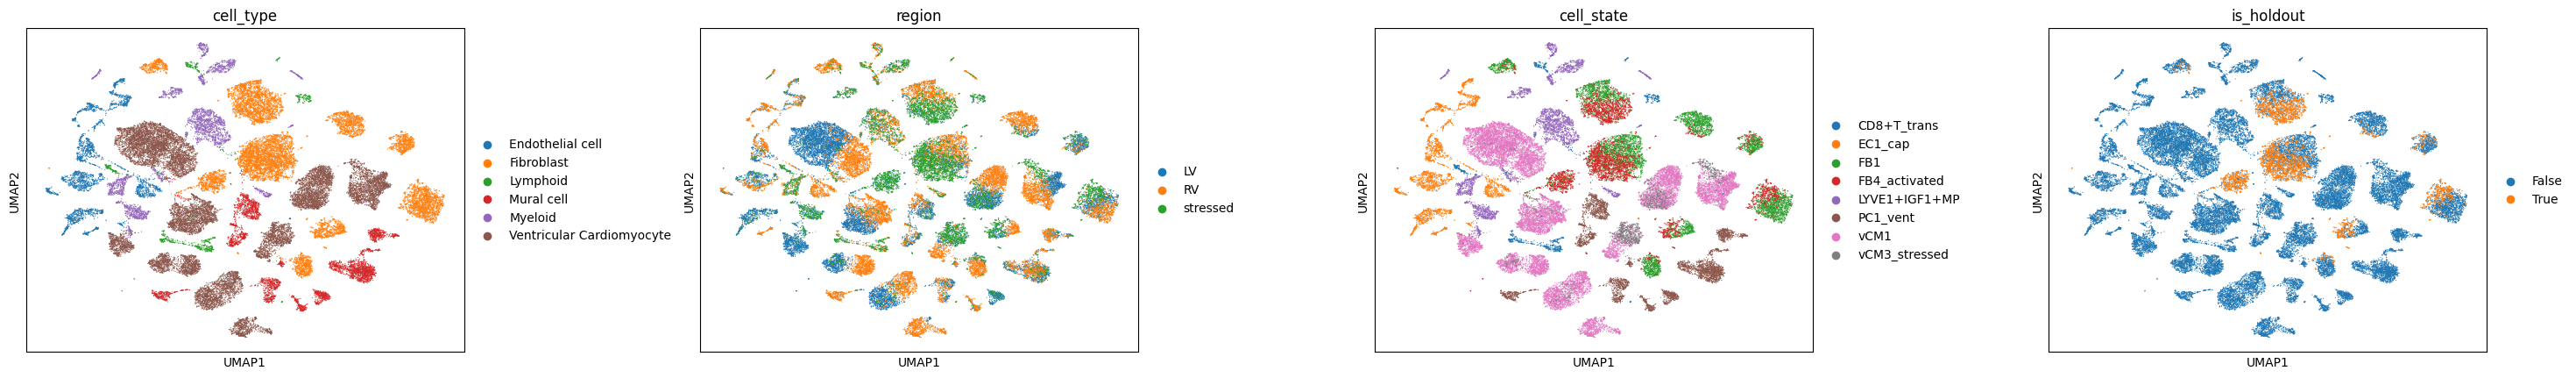

In [ ]:
# UMAP of scvi latent
sc.pl.umap(adata, color=['cell_type', 'region', 'cell_state', 'is_holdout'], wspace=0.4)

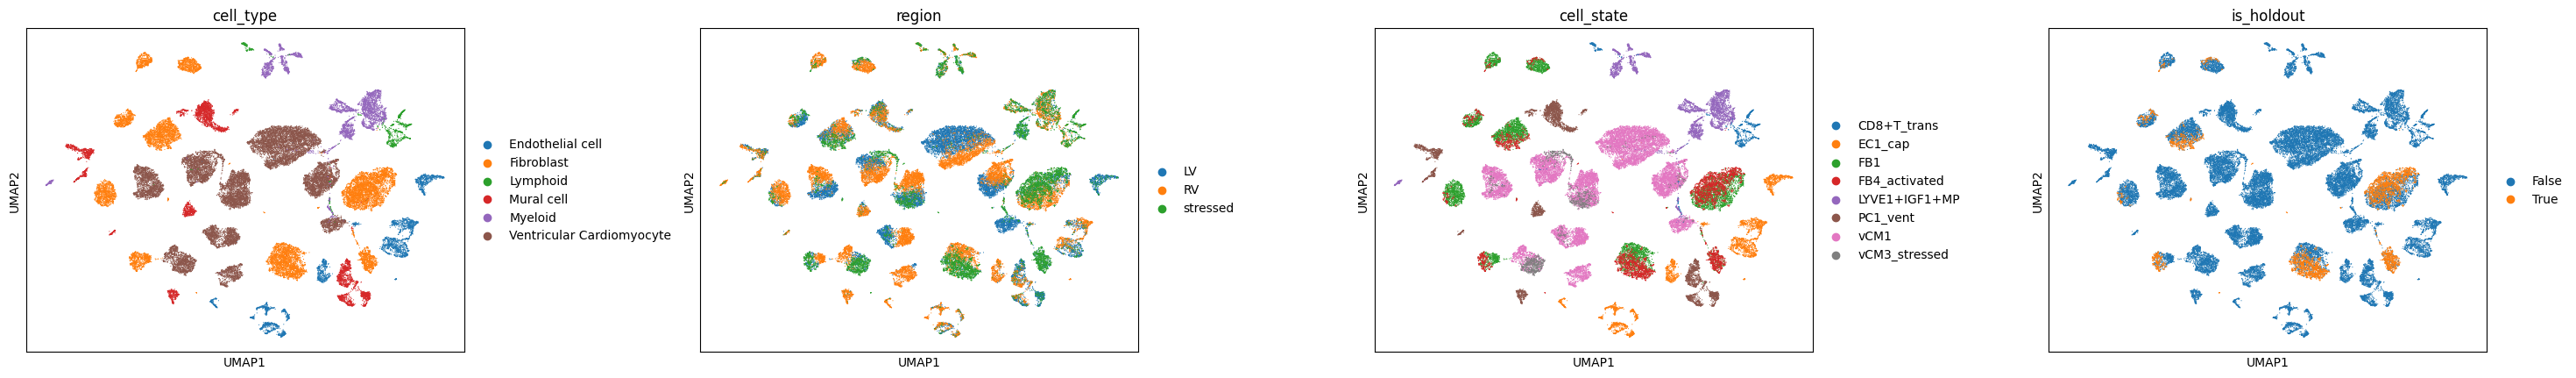

In [ ]:
# UMAP of adata.X
sc.pl.umap(adata, color=['cell_type', 'region', 'cell_state', 'is_holdout'], wspace=0.4)

In [19]:
scvi_results = []
for seed in seeds:
    set_seed(seed)
    save_path = f"{base_path}/trained/scvi_sim_seed_{seed}_{split}"

    model = scvi.model.SCVI.load(save_path, adata)

    mll = model.get_marginal_ll(adata[adata.obs["is_holdout"]], 
                                n_mc_samples=n_mc_samples, 
                                return_mean=True)
    scvi_results.append(mll)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_0_ood/model.pt already downloaded    
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_1_ood/model.pt already downloaded    
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_2_ood/model.pt already downloaded    
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_3_ood/model.pt already downloaded    
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_4_ood/model.pt already downloaded    
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [20]:
# add scvi baseline to results and save
with open(f"../results/mll_sim_results_scvi_{split}.pkl", "wb") as f:
    pickle.dump(scvi_results, f)

# Plot

In [21]:
with open(f"../results/mll_sim_results_scvi_{split}.pkl", "rb") as f:
    scvi_results = pickle.load(f)

In [22]:
with open(f"../results/mll_sim_results_{split}.pkl", "rb") as f:
    results = pickle.load(f)

In [23]:
results['scvi'] = scvi_results

In [24]:
import matplotlib.pyplot as plt

def plot_mll_boxplot(results, title="Marginal LL on holdout (Higher is better)"):
    conditions = list(results.keys())
    data = [results[c] for c in conditions]

    # Assign a color per condition
    colors = ["tab:blue", "tab:orange"]   # add or change colors as needed
    x_labels = ["z+spatial", "spatial only", "scvi"] # Rename labels for plotting

    fig, ax = plt.subplots(figsize=(6, 4))

    bp = ax.boxplot(
        data,
        patch_artist=True,   # allows facecolor
        labels=x_labels,
        medianprops=dict(color='black', linewidth=2)
    )

    # Apply colors to each box
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    # Optional: jittered points overlaid on the boxes
    for i, cond in enumerate(conditions):
        y = np.array(results[cond])
        x = np.random.normal(i+1, 0.04, size=len(y))   # jitter for visibility
        ax.scatter(x, y, color="black", s=30, zorder=3)

    ax.set_ylabel("Marginal LL")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1188418/3003056953.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


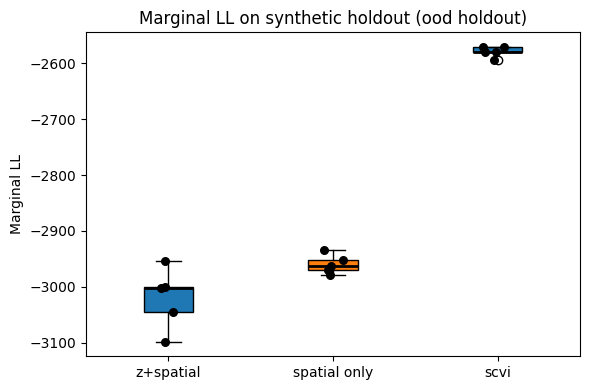

In [25]:
plot_mll_boxplot(results, title=f"Marginal LL on synthetic holdout ({split} holdout)")